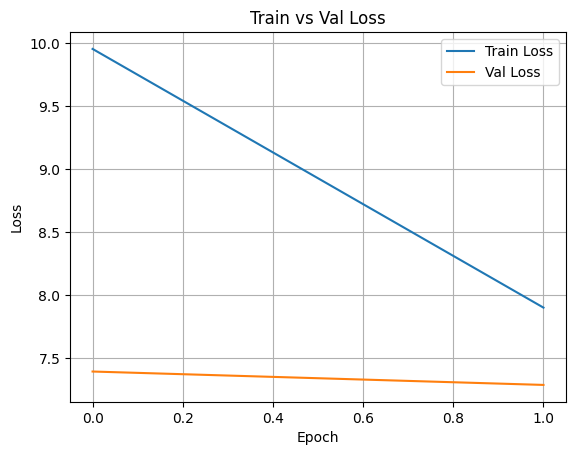

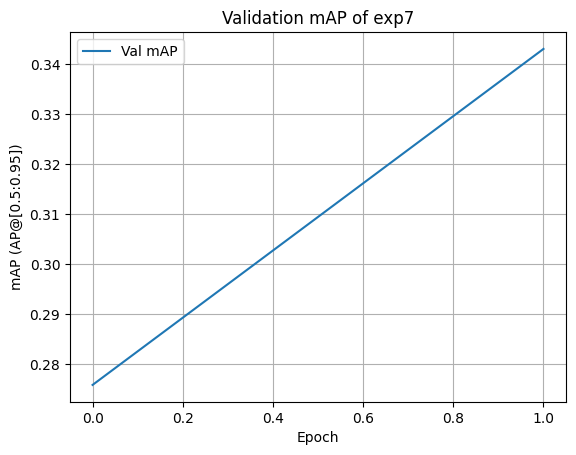

Best epoch: 1, mAP: 0.3430


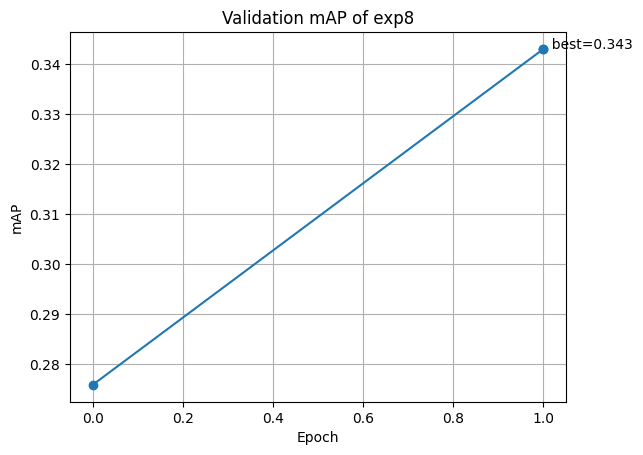

In [ ]:
import json
import matplotlib.pyplot as plt

log_path = f'Deformable-DETR/exp14/r50_deformable_detr_plus_iterative_bbox_refinement_plus_plus_two_stage/log.txt'
epochs = []
train_loss = []
val_loss = []
val_map = []

with open(log_path, "r") as f:
    for i, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        
        data = json.loads(line)

        # train loss
        if "train_loss" in data:
            train_loss.append(data["train_loss"])
        else:
            train_loss.append(None)

        # val loss
        if "test_loss" in data:
            val_loss.append(data["test_loss"])
        else:
            val_loss.append(None)

        # val mAP
        if "test_coco_eval_bbox" in data:
            val_map.append(data["test_coco_eval_bbox"][0])
        else:
            val_map.append(None)

        epochs.append(i)

plt.figure()
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Val Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(epochs, val_map, label="Val mAP")
plt.xlabel("Epoch")
plt.ylabel("mAP (AP@[0.5:0.95])")
plt.title("Validation mAP of exp7")
plt.legend()
plt.grid()
plt.show()


epochs = []
maps = []

with open(log_path, "r") as f:
    for line in f:
        data = json.loads(line)
        if "test_coco_eval_bbox" in data:
            epochs.append(data["epoch"])
            maps.append(data["test_coco_eval_bbox"][0])

# find best
best_idx = maps.index(max(maps))
best_epoch = epochs[best_idx]
best_map = maps[best_idx]

print(f"Best epoch: {best_epoch}, mAP: {best_map:.4f}")

# plot
plt.plot(epochs, maps, marker='o')
plt.scatter(best_epoch, best_map)  # highlight
plt.ztext(best_epoch, best_map, f"  best={best_map:.3f}")

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title(f"Validation mAP of exp8")
plt.grid()
plt.show()

In [2]:
!pip install ensemble-boxes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 4.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.3 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 15.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [ensemble-boxes]m [numba]]e]


In [4]:
import json
from ensemble_boxes import weighted_boxes_fusion

def load_coco(path):
    with open(path) as f:
        data = json.load(f)

    results = {}
    for d in data:
        img_id = d["image_id"]
        if img_id not in results:
            results[img_id] = {"boxes": [], "scores": [], "labels": []}

        x, y, w, h = d["bbox"]
        box = [x/512, y/512, (x+w)/512, (y+h)/512]

        results[img_id]["boxes"].append(box)
        results[img_id]["scores"].append(d["score"])
        results[img_id]["labels"].append(d["category_id"])

    return results

paths = ["/Deformable-DETR/outputs/pred_7_13.json",
         "/Deformable-DETR/outputs/pred_8_12.json",
         "/Deformable-DETR/outputs/pred_exp13_15.json",
         "/Deformable-DETR/outputs/pred_8_10.json",
         "/Deformable-DETR/outputs/pred_6_12.json"]

all_preds = [load_coco(p) for p in paths]

final = []

for img_id in all_preds[0].keys():

    boxes_list = [p[img_id]["boxes"] for p in all_preds]
    scores_list = [p[img_id]["scores"] for p in all_preds]
    labels_list = [p[img_id]["labels"] for p in all_preds]

    boxes, scores, labels = weighted_boxes_fusion(
        boxes_list,
        scores_list,
        labels_list,
        iou_thr=0.5,
        skip_box_thr=0.05
    )

    for b, s, l in zip(boxes, scores, labels):
        x1, y1, x2, y2 = b
        final.append({
            "image_id": img_id,
            "category_id": int(l),
            "bbox": [
                x1*512,
                y1*512,
                (x2-x1)*512,
                (y2-y1)*512
            ],
            "score": float(s)
        })

with open("ensemble.json", "w") as f:
    json.dump(final, f)

/home/anlt/miniconda3/envs/hw2/lib/python3.10/site-packages/ensemble_boxes/ensemble_boxes_wbf.py:45: UserWarning: X1 > 1 in box. Set it to 1. Check that you normalize boxes in [0, 1] range.
  warnings.warn('X1 > 1 in box. Set it to 1. Check that you normalize boxes in [0, 1] range.')
/home/anlt/miniconda3/envs/hw2/lib/python3.10/site-packages/ensemble_boxes/ensemble_boxes_wbf.py:51: UserWarning: X2 > 1 in box. Set it to 1. Check that you normalize boxes in [0, 1] range.
  warnings.warn('X2 > 1 in box. Set it to 1. Check that you normalize boxes in [0, 1] range.')
/home/anlt/miniconda3/envs/hw2/lib/python3.10/site-packages/ensemble_boxes/ensemble_boxes_wbf.py:66: UserWarning: Zero area box skipped: [1.0444419384002686, 0.49233078956604004, 1.1173521280288696, 0.591296374797821].
  warnings.warn("Zero area box skipped: {}.".format(box_part))
/home/anlt/miniconda3/envs/hw2/lib/python3.10/site-packages/ensemble_boxes/ensemble_boxes_wbf.py:66: UserWarning: Zero area box skipped: [1.03907179